# Exercise 3

In this exercise, you will analyse a dataset obtained from the London transport system (TfL). The data is in a filled called `tfl_readership.csv` (comma-separated-values format).  As in Exercise 2, we will load and view the data using  `pandas`.

In [1]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# Load data
df_tfl = pd.read_csv('/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv'

df_tfl.head(13)

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
0,2000/01,P 01,01 Apr '00,29 Apr '00,29d,884,0,0,210,231,...,0,655,1066,200,2509,0,0,96,45.8,0.0
1,2000/01,P 02,30 Apr '00,27 May '00,28d,949,0,0,214,205,...,0,605,1168,217,2598,0,0,93,46.5,0.0
2,2000/01,P 03,28 May '00,24 Jun '00,28d,945,0,0,209,221,...,0,650,1154,212,2623,0,0,98,47.1,0.0
3,2000/01,P 04,25 Jun '00,22 Jul '00,28d,981,0,0,216,241,...,0,708,1196,214,2761,0,0,105,50.8,0.0
4,2000/01,P 05,23 Jul '00,19 Aug '00,28d,958,0,0,225,248,...,0,730,1165,165,2643,0,0,103,50.3,0.0
5,2000/01,P 06,20 Aug '00,16 Sep '00,28d,984,0,0,243,236,...,0,702,1164,151,2608,0,0,100,49.2,0.0
6,2000/01,P 07,17 Sep '00,14 Oct '00,28d,1001,0,0,205,216,...,0,639,1286,196,2763,0,0,107,48.8,0.0
7,2000/01,P 08,15 Oct '00,11 Nov '00,28d,979,0,0,199,221,...,0,668,1298,220,2819,0,0,113,51.5,0.0
8,2000/01,P 09,12 Nov '00,09 Dec '00,28d,971,0,0,184,212,...,0,640,1302,242,2839,0,0,114,54.0,0.0
9,2000/01,P 10,10 Dec '00,06 Jan '01,28d,912,0,0,192,211,...,0,631,993,195,2359,0,0,90,55.3,0.0


Each row of our data frame represents the average daily ridership over a 28/29 day period for various types of transport and tickets (bus, tube etc.).  We have used the `.head()` command to display the top 13 rows of the data frame (corresponding to one year).  Focusing on the "Tube Total" column, notice the dip in ridership in row 9 (presumably due to Christmas/New Year's), and also the slight dip during the summer (rows 4,5).

In [5]:
#df_tfl.sample(3)  #random sample of 3 rows
df_tfl.tail(3)  #last 3 rows

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
242,2018/19,P 09,11 Nov '18,08 Dec '18,28d,0,1110,1089,0,41,...,1399,249,1017,334,4221,996,557,355,84.1,2.6
243,2018/19,P 10,09 Dec '18,05 Jan '19,28d,0,1001,949,0,38,...,1110,242,632,259,3279,750,414,270,66.3,3.2
244,2018/19,P 11,06 Jan '19,02 Feb '19,28d,0,1036,1075,0,30,...,1310,204,924,305,3809,929,517,333,79.3,2.3


The dataframe contains $N=245$ counting periods (of 28/29 days each) from 1 April 2000 to  2 Feb 2019. We now define a numpy array consisting of the values in the ' Tube Total (000s)' column:

In [6]:
yvals = np.array(df_tfl['Tube Total (000s)'])
N = np.size(yvals)
xvals = np.linspace(1,N,N) #an array containing the values 1,2....,N

We now have a time series consisting of points $(x_i,y_i)$, for $i = 1, \ldots, N$, where $y_i$ is the average daily tube rideship in counting period $x_i = i$.

## 3a) Plot the data in a scatterplot

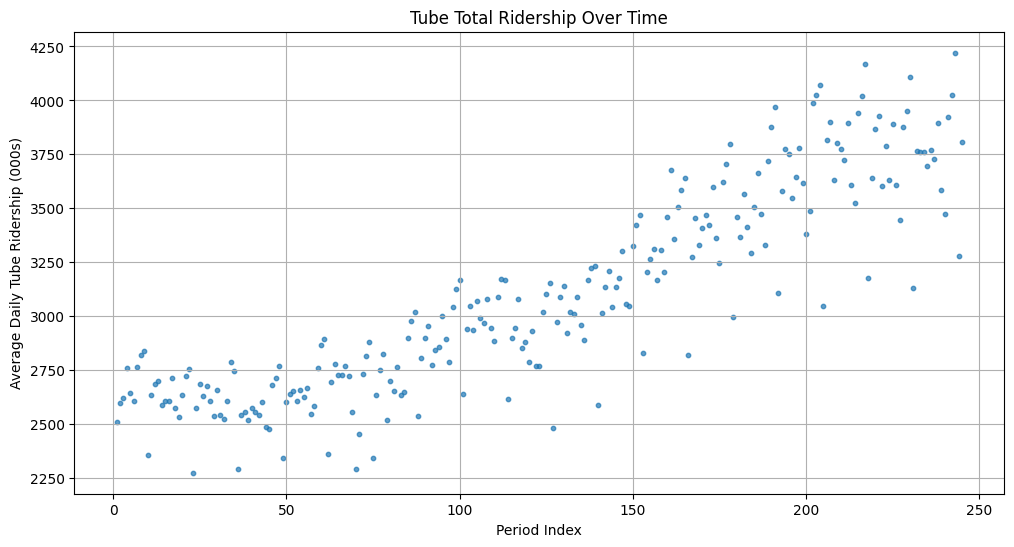

In [7]:
plt.figure(figsize=(12, 6))
plt.scatter(xvals, yvals, s=10, alpha=0.7)
plt.title('Tube Total Ridership Over Time')
plt.xlabel('Period Index')
plt.ylabel('Average Daily Tube Ridership (000s)')
plt.grid(True)
plt.show()

## 3b) Fit a linear model $f(x) = \beta_0 + \beta_1 x$ to the data

- Print the values of the regression coefficients $\beta_0, \beta_1$ determined using least-squares.
- Plot the fitted model and the scatterplot on the same plot.
- Compute and print the **MSE** and the $R^2$ coefficient for the fitted model.

All numerical outputs should be displayed to three decimal places.

Regression Coefficients:
  beta_0: 2367.382
  beta_1: 5.939


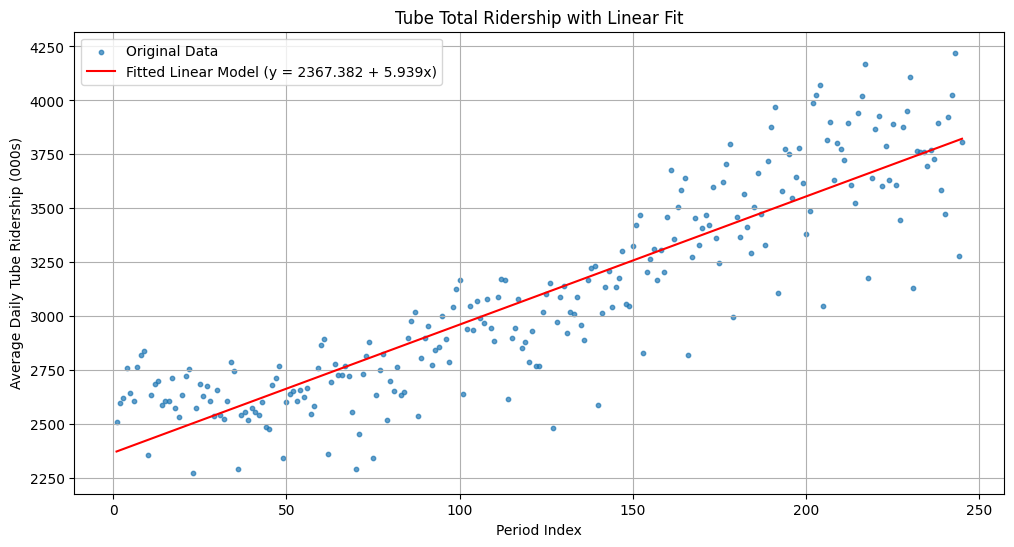

Mean Squared Error (MSE): 45323.636
R-squared (R^2): 0.796


In [8]:
# Construct the design matrix X for a linear model f(x) = beta_0 + beta_1 * x
X = np.vstack([np.ones(N), xvals]).T

# Solve for the regression coefficients using least squares
beta = np.linalg.lstsq(X, yvals, rcond=None)[0]
beta_0 = beta[0]
beta_1 = beta[1]

print(f"Regression Coefficients:\n  beta_0: {beta_0:.3f}\n  beta_1: {beta_1:.3f}")

# Calculate the predicted y values
y_pred_linear = X @ beta

# Plot the scatterplot and the fitted model
plt.figure(figsize=(12, 6))
plt.scatter(xvals, yvals, s=10, alpha=0.7, label='Original Data')
plt.plot(xvals, y_pred_linear, color='red', label=f'Fitted Linear Model (y = {beta_0:.3f} + {beta_1:.3f}x)')
plt.title('Tube Total Ridership with Linear Fit')
plt.xlabel('Period Index')
plt.ylabel('Average Daily Tube Ridership (000s)')
plt.grid(True)
plt.legend()
plt.show()

# Compute MSE
mse_linear = np.mean((yvals - y_pred_linear)**2)
print(f"Mean Squared Error (MSE): {mse_linear:.3f}")

# Compute R-squared
total_sum_squares = np.sum((yvals - np.mean(yvals))**2)
residual_sum_squares = np.sum((yvals - y_pred_linear)**2)
r_squared_linear = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared (R^2): {r_squared_linear:.3f}")

## 3c)  Plotting the residuals

- Plot the residuals on a scatterplot
- Also plot the residuals over a short duration and comment on whether you can discern any periodic components.

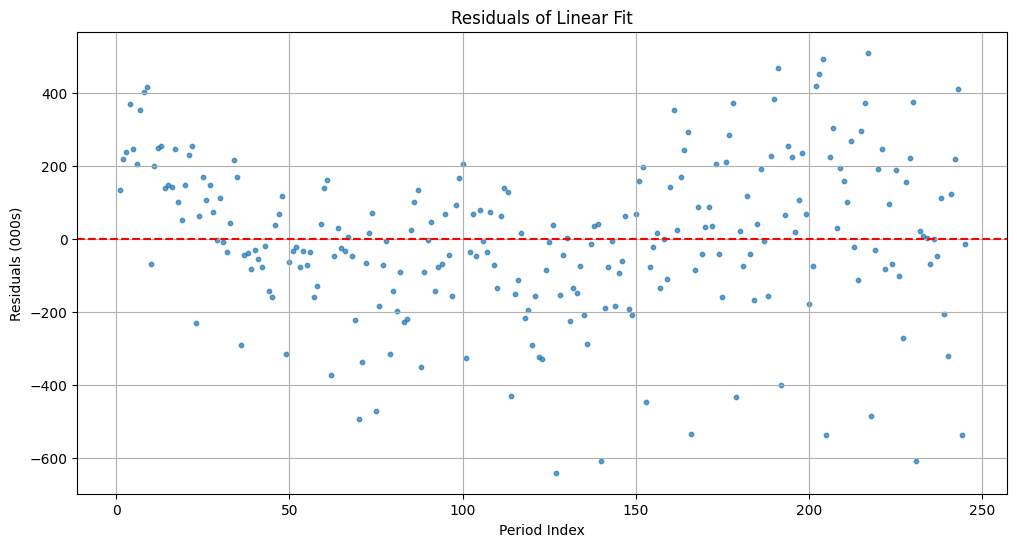

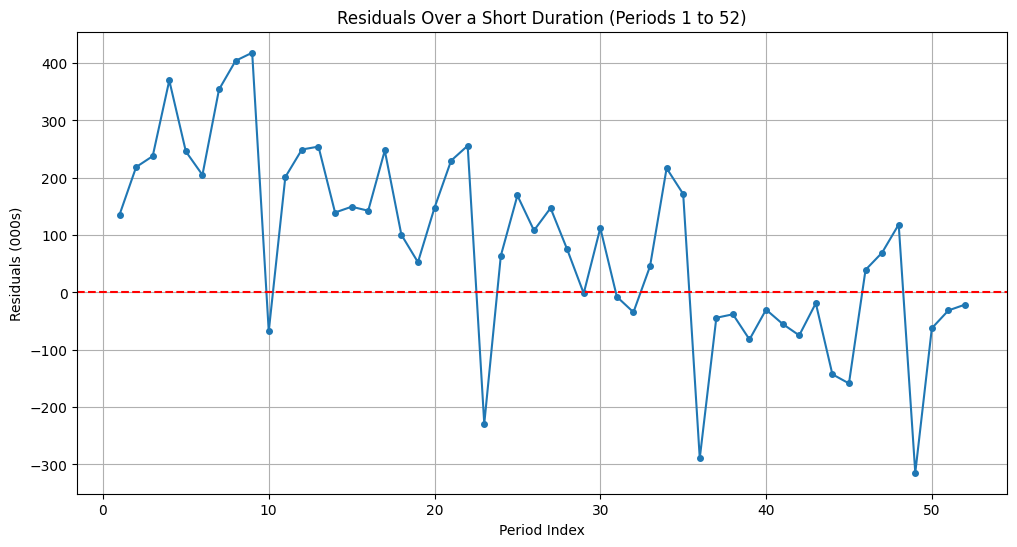

In [9]:
# Calculate residuals
residuals = yvals - y_pred_linear

# Plot the residuals
plt.figure(figsize=(12, 6))
plt.scatter(xvals, residuals, s=10, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals of Linear Fit')
plt.xlabel('Period Index')
plt.ylabel('Residuals (000s)')
plt.grid(True)
plt.show()

# Plot residuals over a short duration to discern periodic components
short_duration_start = 1
short_duration_end = 52 # Approximately one year of data (52 weeks / 28-day periods)

plt.figure(figsize=(12, 6))
plt.plot(xvals[short_duration_start-1:short_duration_end], residuals[short_duration_start-1:short_duration_end], marker='o', linestyle='-', markersize=4)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residuals Over a Short Duration (Periods {short_duration_start} to {short_duration_end})')
plt.xlabel('Period Index')
plt.ylabel('Residuals (000s)')
plt.grid(True)
plt.show()

There seems to be a periodicity added to a linear trend term.

### 3d) Periodogram

- Compute and plot the peridogram of the residuals. (Recall that the periodogram is the squared-magnitude of the DFT coefficients.)
- Identify the indices/frequencies for which the periogram value exceeds **50%** of the maximum.


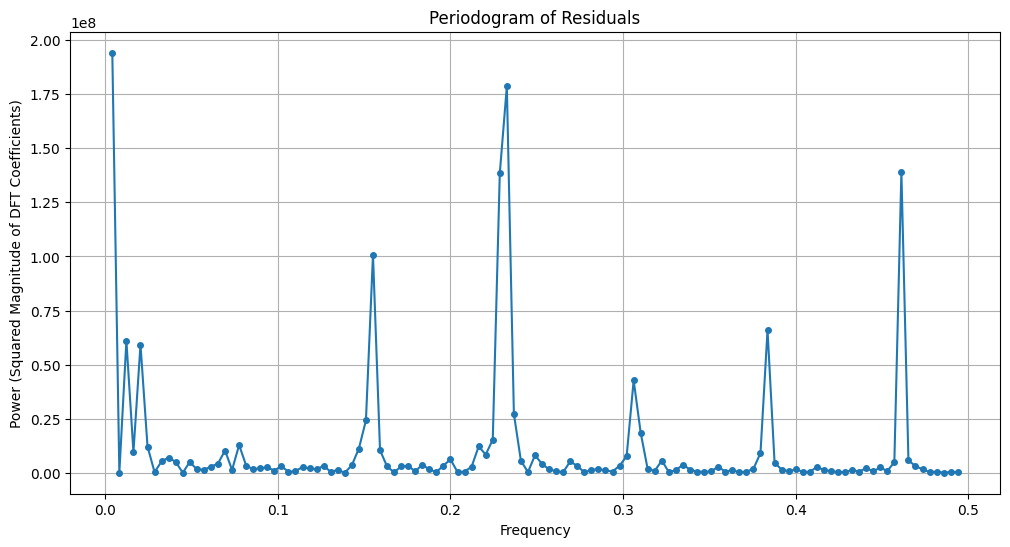

In [12]:
# Compute the Discrete Fourier Transform (DFT) of the residuals
fft_residuals = np.fft.fft(residuals)

# Compute the squared magnitude of the DFT coefficients (periodogram)
periodogram = np.abs(fft_residuals)**2

# Get frequencies corresponding to the DFT coefficients
frequencies = np.fft.fftfreq(N, d=1) # d=1 because xvals are 1, 2, ... N

# We are interested in the positive frequencies for real-valued signals
# The periodogram is symmetric, so we take the first half.
half_N = N // 2
positive_frequencies = frequencies[1:half_N]
positive_periodogram = periodogram[1:half_N]

# Plot the periodogram
plt.figure(figsize=(12, 6))
plt.plot(positive_frequencies, positive_periodogram, marker='o', linestyle='-', markersize=4)
plt.title('Periodogram of Residuals')
plt.xlabel('Frequency')
plt.ylabel('Power (Squared Magnitude of DFT Coefficients)')
plt.grid(True)
plt.show()

In [13]:
# Identify indices/frequencies where periodogram value exceeds 50% of the maximum
max_periodogram = np.max(positive_periodogram)
threshold = 0.5 * max_periodogram

# Find the indices where the periodogram exceeds the threshold
strong_frequency_indices = np.where(positive_periodogram > threshold)[0]

# Get the actual frequencies corresponding to these indices
strong_frequencies = positive_frequencies[strong_frequency_indices]

print(f"Maximum periodogram value: {max_periodogram:.3f}")
print(f"Threshold (50% of max): {threshold:.3f}")
print(f"Indices where periodogram > 50% of max: {strong_frequency_indices}")
print(f"Frequencies corresponding to these indices: {strong_frequencies}")

Maximum periodogram value: 194187481.567
Threshold (50% of max): 97093740.783
Indices where periodogram > 50% of max: [  0  37  55  56 112]
Frequencies corresponding to these indices: [0.00408163 0.15510204 0.22857143 0.23265306 0.46122449]


## 3e) To the residuals,  fit a model of the form  

$$ \beta_{1s} \sin(\omega_1 x) + \beta_{1c} \cos(\omega_1 x) + \beta_{2s} \sin(\omega_2 x) + \beta_{2c} \cos(\omega_2 x) + \ldots + \beta_{Ks} \sin(\omega_K x) + \beta_{Kc} \cos(\omega_K x).$$

The frequencies $\omega_1, \ldots, \omega_K$ in the model are those corresponding to the indices identified in Part 2c. (Hint: Each of the sines and cosines will correspond to one column in your X-matrix.)

- Print the values of the regression coefficients obtained using least-squares.

All numerical outputs should be displayed to three decimal places.

In [14]:
# Construct the design matrix for the periodic model
X_periodic = np.zeros((N, 2 * len(strong_frequencies)))

for i, freq in enumerate(strong_frequencies):
    # For a frequency omega, we need sin(2 * pi * omega * x) and cos(2 * pi * omega * x)
    # The frequencies from fftfreq are already normalized such that multiplying by xvals
    # directly gives the phase in cycles. So we multiply by 2*pi for radians.
    X_periodic[:, 2*i] = np.sin(2 * np.pi * freq * xvals)
    X_periodic[:, 2*i + 1] = np.cos(2 * np.pi * freq * xvals)

# Solve for the regression coefficients using least squares on the residuals
beta_periodic = np.linalg.lstsq(X_periodic, residuals, rcond=None)[0]

print("Regression Coefficients for Periodic Model:")
for i, freq in enumerate(strong_frequencies):
    print(f"  Frequency {freq:.6f}: beta_sin: {beta_periodic[2*i]:.3f}, beta_cos: {beta_periodic[2*i + 1]:.3f}")

Regression Coefficients for Periodic Model:
  Frequency 0.004082: beta_sin: -51.253, beta_cos: 101.556
  Frequency 0.155102: beta_sin: 61.628, beta_cos: -54.006
  Frequency 0.228571: beta_sin: -15.581, beta_cos: -94.797
  Frequency 0.232653: beta_sin: 81.659, beta_cos: 72.381
  Frequency 0.461224: beta_sin: 32.472, beta_cos: 90.589


3f) The combined fit
Plot the combined fit together with a scatterplot of the data
Compute and print the final MSE and
 coefficient. Comment on the improvement over the linear fit.
The combined fit, which corresponds to the full model


can be obtained by adding the fits in parts 2b) and 2e).

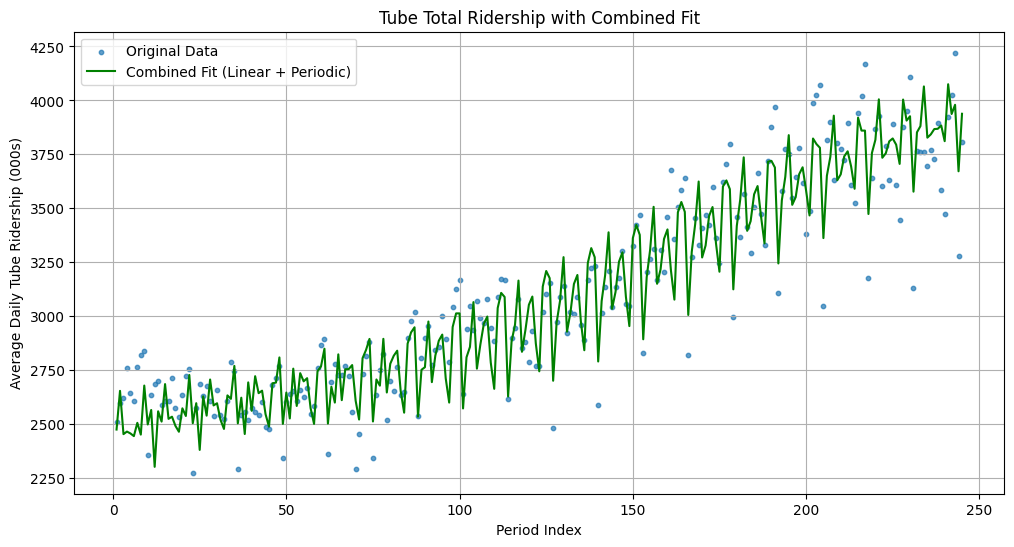

Final Mean Squared Error (MSE) for combined model: 20297.501
Final R-squared (R^2) for combined model: 0.908

Improvement over linear fit:
  MSE reduction: 25026.135
  R^2 increase: 0.113


In [15]:
# Calculate the predicted y values from the periodic model
y_pred_periodic = X_periodic @ beta_periodic

# Combine the linear and periodic fits
y_pred_combined = y_pred_linear + y_pred_periodic

# Plot the combined fit and the scatterplot of the data
plt.figure(figsize=(12, 6))
plt.scatter(xvals, yvals, s=10, alpha=0.7, label='Original Data')
plt.plot(xvals, y_pred_combined, color='green', label='Combined Fit (Linear + Periodic)')
plt.title('Tube Total Ridership with Combined Fit')
plt.xlabel('Period Index')
plt.ylabel('Average Daily Tube Ridership (000s)')
plt.grid(True)
plt.legend()
plt.show()

# Compute MSE for the combined model
mse_combined = np.mean((yvals - y_pred_combined)**2)
print(f"Final Mean Squared Error (MSE) for combined model: {mse_combined:.3f}")

# Compute R-squared for the combined model
total_sum_squares = np.sum((yvals - np.mean(yvals))**2)
residual_sum_squares_combined = np.sum((yvals - y_pred_combined)**2)
r_squared_combined = 1 - (residual_sum_squares_combined / total_sum_squares)
print(f"Final R-squared (R^2) for combined model: {r_squared_combined:.3f}")

print(f"\nImprovement over linear fit:")
print(f"  MSE reduction: {mse_linear - mse_combined:.3f}")
print(f"  R^2 increase: {r_squared_combined - r_squared_linear:.3f}")


The combined fit takes care of the short term periodic variations which the orignal low order trend line didn't capture. The periodic term is reasonable as the variation of tube users would be cyclic in nature as fluctuations may vary in a similar way over weeks or months.